# XAI Chest X-ray Classification
## Model 3: VGG16 Feature Extractor + SVM Classifier

This notebook uses **VGG16** as a pretrained feature extractor and **Support Vector Machine (SVM)** as the final classifier for multi-class chest X-ray disease classification.

## 1. Install and Import Libraries

In [2]:
!pip install kagglehub lime shap -q

In [3]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from lime import lime_image
from skimage.segmentation import mark_boundaries

import shap

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Download Dataset

In [4]:
import kagglehub

path = kagglehub.dataset_download("fernando2rad/x-ray-lung-diseases-images-9-classes")
print("Dataset path:", path)

Using Colab cache for faster access to the 'x-ray-lung-diseases-images-9-classes' dataset.
Dataset path: /kaggle/input/x-ray-lung-diseases-images-9-classes


## 3. Dataset Root

In [5]:
# The KaggleHub path already contains the 9 class folders directly.
DATASET_ROOT = path

print("Dataset root:", DATASET_ROOT)
print("Folders found:")
for folder in sorted(os.listdir(DATASET_ROOT)):
    folder_path = os.path.join(DATASET_ROOT, folder)
    if os.path.isdir(folder_path):
        print("-", folder)

Dataset root: /kaggle/input/x-ray-lung-diseases-images-9-classes
Folders found:
- 00 Anatomia Normal
- 01 Processos Inflamatórios Pulmonares (Pneumonia)
- 02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)
- 03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)
- 04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)
- 05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)
- 06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Metastases)
- 07 Alterações de Mediastino (Pericardite, Malformações Arteriovenosas, Linfonodomegalias)
- 08 Alterações do Tórax (Atelectasias, Malformações, Agenesia, Hipoplasias)


## 4. Build DataFrame

In [6]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

all_files = []

for class_name in sorted(os.listdir(DATASET_ROOT)):
    class_path = os.path.join(DATASET_ROOT, class_name)

    if not os.path.isdir(class_path):
        continue

    for file_name in os.listdir(class_path):
        if file_name.lower().endswith(image_extensions):
            all_files.append({
                "filepath": os.path.join(class_path, file_name),
                "label": class_name
            })

df = pd.DataFrame(all_files)

print("Total images:", len(df))
print("Number of classes:", df["label"].nunique())
print(df["label"].value_counts())

assert df["label"].nunique() == 9, "Dataset should contain 9 classes. Check DATASET_ROOT."

df.head()

Total images: 6743
Number of classes: 9
label
00 Anatomia Normal                                                                           1340
01 Processos Inflamatórios Pulmonares (Pneumonia)                                            1060
02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)          678
06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Metastases)              658
04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)        644
03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)                           629
07 Alterações de Mediastino (Pericardite, Malformações Arteriovenosas, Linfonodomegalias)     596
05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)           594
08 Alterações do Tórax (Atelectasias, Malformações, Agenesia, Hipoplasias)                    544
Name: count, dtype: int64


,filepath,label
0,/kaggle/input/x-ray-lung-diseases-images-9-cla...,00 Anatomia Normal
1,/kaggle/input/x-ray-lung-diseases-images-9-cla...,00 Anatomia Normal
2,/kaggle/input/x-ray-lung-diseases-images-9-cla...,00 Anatomia Normal
3,/kaggle/input/x-ray-lung-diseases-images-9-cla...,00 Anatomia Normal
4,/kaggle/input/x-ray-lung-diseases-images-9-cla...,00 Anatomia Normal


## 5. Clean Data

In [8]:
df = df.drop_duplicates(subset=["filepath"]).reset_index(drop=True)

print("Number of images:", len(df))
print("Number of classes:", df["label"].nunique())
print(df["label"].value_counts())

Number of images: 6743
Number of classes: 9
label
00 Anatomia Normal                                                                           1340
01 Processos Inflamatórios Pulmonares (Pneumonia)                                            1060
02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)          678
06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Metastases)              658
04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)        644
03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)                           629
07 Alterações de Mediastino (Pericardite, Malformações Arteriovenosas, Linfonodomegalias)     596
05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)           594
08 Alterações do Tórax (Atelectasias, Malformações, Agenesia, Hipoplasias)                    544
Name: count, dtype: int64


## 6. Exploratory Data Analysis (EDA)

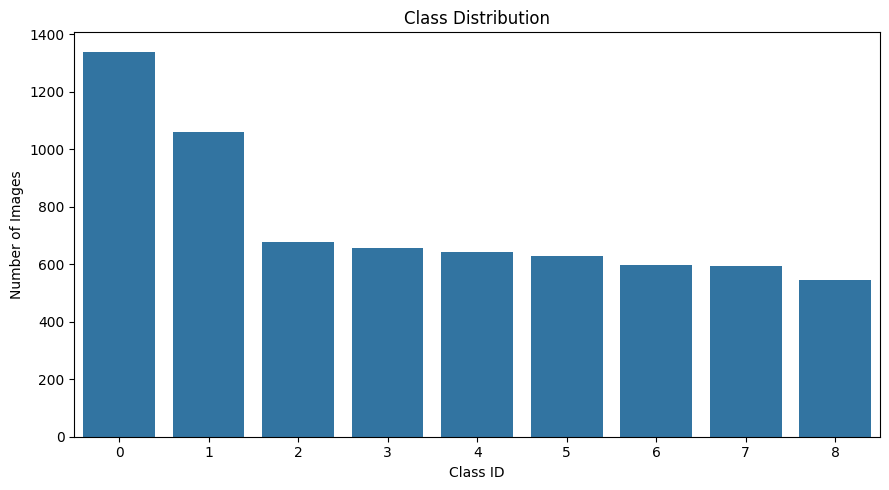

Class Index Mapping:
0: 00 Anatomia Normal
1: 01 Processos Inflamatórios Pulmonares (Pneumonia)
2: 02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)
3: 06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Metastases)
4: 04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)
5: 03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)
6: 07 Alterações de Mediastino (Pericardite, Malformações Arteriovenosas, Linfonodomegalias)
7: 05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)
8: 08 Alterações do Tórax (Atelectasias, Malformações, Agenesia, Hipoplasias)


In [9]:

class_names = list(df["label"].value_counts().index)

class_mapping = {i: name for i, name in enumerate(class_names)}
label_to_id = {name: i for i, name in class_mapping.items()}

df_plot = df.copy()
df_plot["class_id"] = df_plot["label"].map(label_to_id)

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_plot,
    x="class_id",
    order=sorted(df_plot["class_id"].unique())
)

plt.title("Class Distribution")
plt.xlabel("Class ID")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Class Index Mapping:")
for idx, name in class_mapping.items():
    print(f"{idx}: {name}")

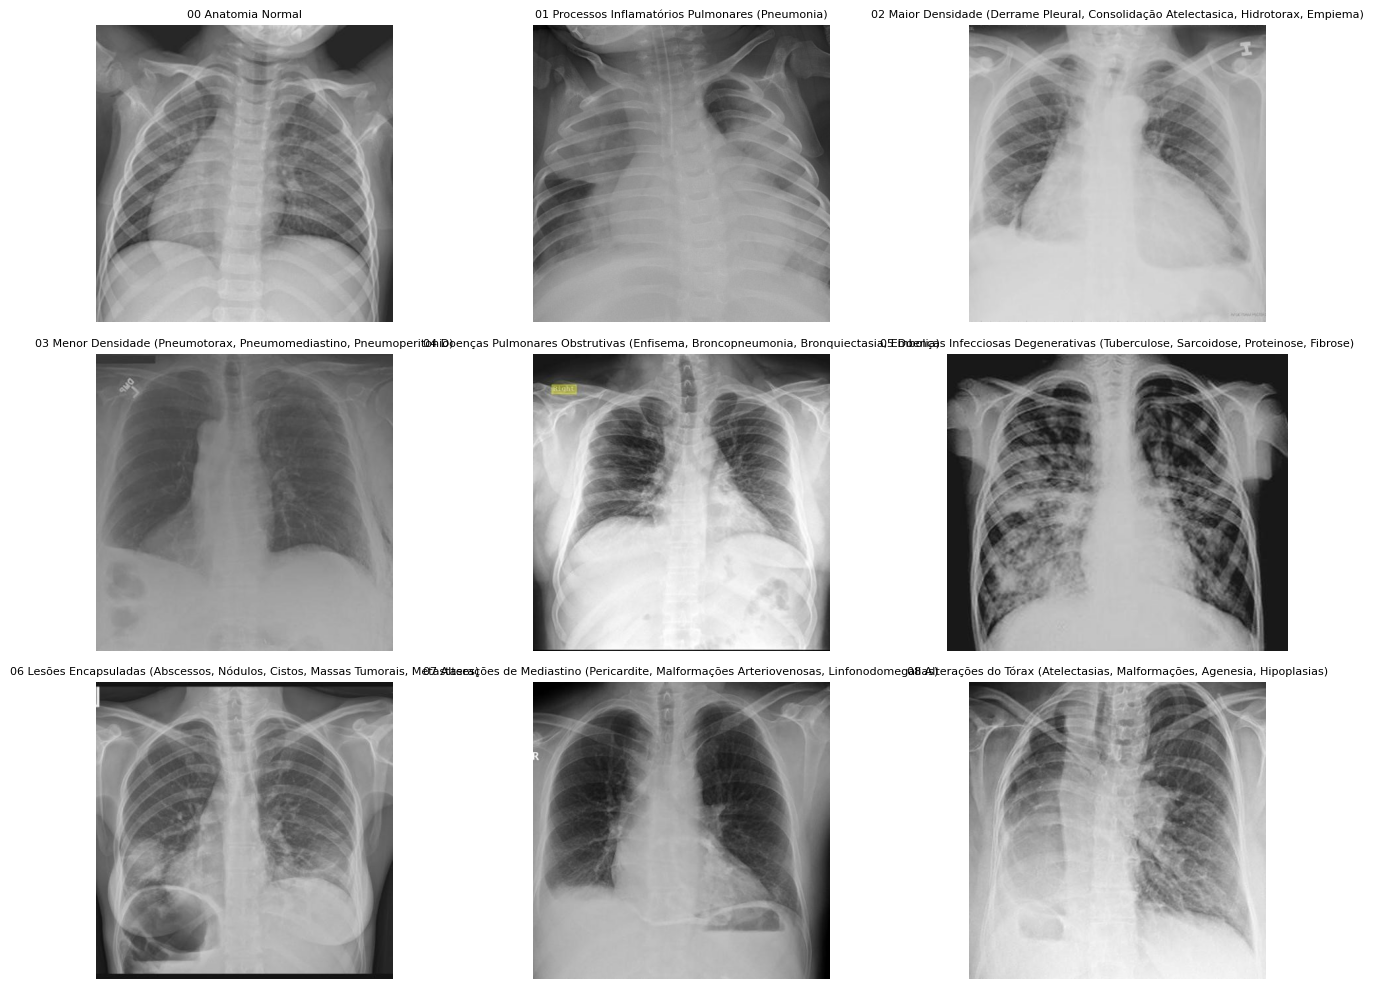

In [10]:
sample_df = df.groupby("label").sample(1, random_state=SEED).reset_index(drop=True)

plt.figure(figsize=(14, 10))

for i, row in sample_df.iterrows():
    img = cv2.imread(row["filepath"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(row["label"], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 7. Train / Validation / Test Split

In [11]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (4720, 2)
Validation: (1011, 2)
Test: (1012, 2)


## 8. Parameters

In [12]:
IMG_SIZE = 224
BATCH_SIZE = 32

## 9. Data Generators

In [13]:
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_gen = datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_gen = datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 4720 validated image filenames belonging to 9 classes.
Found 1011 validated image filenames belonging to 9 classes.
Found 1012 validated image filenames belonging to 9 classes.


In [14]:
print(train_gen.class_indices)
print("Number of classes:", len(train_gen.class_indices))

{'00 Anatomia Normal': 0, '01 Processos Inflamatórios Pulmonares (Pneumonia)': 1, '02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)': 2, '03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)': 3, '04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)': 4, '05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)': 5, '06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Metastases)': 6, '07 Alterações de Mediastino (Pericardite, Malformações Arteriovenosas, Linfonodomegalias)': 7, '08 Alterações do Tórax (Atelectasias, Malformações, Agenesia, Hipoplasias)': 8}
Number of classes: 9


## 10. Build VGG16 Feature Extractor

In [15]:
base_vgg = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_vgg.trainable = False

x = base_vgg.output
x = GlobalAveragePooling2D()(x)

feature_extractor = Model(
    inputs=base_vgg.input,
    outputs=x
)

feature_extractor.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

## 11. Extract Features

In [16]:
X_train = feature_extractor.predict(train_gen, verbose=1)
X_val = feature_extractor.predict(val_gen, verbose=1)
X_test = feature_extractor.predict(test_gen, verbose=1)

y_train = train_gen.classes
y_val = val_gen.classes
y_test = test_gen.classes

print("Train features:", X_train.shape)
print("Validation features:", X_val.shape)
print("Test features:", X_test.shape)

148/148 ━━━━━━━━━━━━━━━━━━━━ 58s 304ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 518ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 519ms/step
Train features: (4720, 512)
Validation features: (1011, 512)
Test features: (1012, 512)


## 12. Train SVM Classifier

In [17]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=SEED
    ))
])

svm_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm',
                 SVC(C=10, class_weight='balanced', probability=True,
                     random_state=42))])

## 13. Evaluation

In [18]:
y_pred = svm_model.predict(X_test)
y_pred_proba = svm_model.predict_proba(X_test)

svm_acc = accuracy_score(y_test, y_pred)

print("VGG16 + SVM Test Accuracy:", svm_acc)

VGG16 + SVM Test Accuracy: 0.9920948616600791


## 14. Confusion Matrix

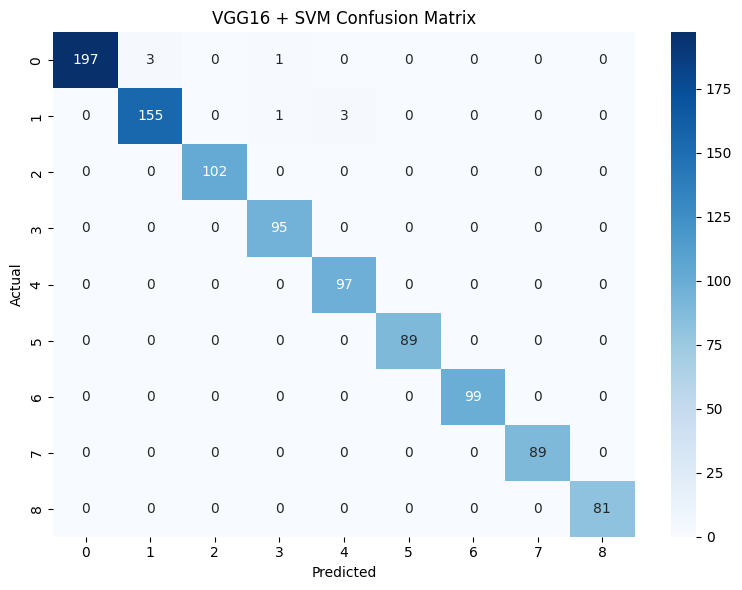

Class Index Mapping:
0: 00 Anatomia Normal
1: 01 Processos Inflamatórios Pulmonares (Pneumonia)
2: 02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)
3: 03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)
4: 04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)
5: 05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)
6: 06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Metastases)
7: 07 Alterações de Mediastino (Pericardite, Malformações Arteriovenosas, Linfonodomegalias)
8: 08 Alterações do Tórax (Atelectasias, Malformações, Agenesia, Hipoplasias)


In [19]:
class_names = list(test_gen.class_indices.keys())

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(len(class_names)),
    yticklabels=range(len(class_names))
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("VGG16 + SVM Confusion Matrix")
plt.tight_layout()
plt.show()

print("Class Index Mapping:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

## 15. Classification Report

In [20]:
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

                                                                                           precision    recall  f1-score   support

                                                                       00 Anatomia Normal       1.00      0.98      0.99       201
                                        01 Processos Inflamatórios Pulmonares (Pneumonia)       0.98      0.97      0.98       159
     02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)       1.00      1.00      1.00       102
                      03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)       0.98      1.00      0.99        95
   04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)       0.97      1.00      0.98        97
      05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)       1.00      1.00      1.00        89
         06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Meta

In [35]:
train_pred = svm_model.predict(X_train)
val_pred = svm_model.predict(X_val)
test_pred = svm_model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
val_acc = accuracy_score(y_val, val_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9997881355932203
Validation Accuracy: 0.9920870425321464
Test Accuracy: 0.9920948616600791


In [36]:
train_paths = set(train_df["filepath"])
val_paths = set(val_df["filepath"])
test_paths = set(test_df["filepath"])

print("Train-Val overlap:", len(train_paths.intersection(val_paths)))
print("Train-Test overlap:", len(train_paths.intersection(test_paths)))
print("Val-Test overlap:", len(val_paths.intersection(test_paths)))

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


## 16. Prediction Function

In [24]:
def clean_label(label):
    label = label.split(" ", 1)[-1]

    shortcuts = {
        "Anatomia Normal": "Normal",
        "Processos Inflamatórios Pulmonares (Pneumonia)": "Pneumonia",
        "Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)": "Fibrose",
        "Alterações de Mediastino (Pericardite, Malformações Arteriovenosas, Linfonodomegalias)": "Mediastino",
        "Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Metastases)": "Metastases",
        "Doenças Pulmonares Obstrutivas": "Obstructive",
        "Maior Densidade": "Maior Densidade",
        "Menor Densidade": "Menor Densidade",
        "Alterações do Tórax": "Torax"
    }

    return shortcuts.get(label, label[:20])


def predict_image_vgg_svm(img_path):
    if not os.path.exists(img_path):
        return None, None, None

    img = cv2.imread(img_path)
    if img is None:
        return None, None, None

    img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img_display, (IMG_SIZE, IMG_SIZE))
    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = preprocess_input(img_array)

    features = feature_extractor.predict(img_array, verbose=0)

    pred_idx = svm_model.predict(features)[0]
    pred_probs = svm_model.predict_proba(features)[0]
    confidence = np.max(pred_probs)

    class_name = class_names[pred_idx]
    pred_label = clean_label(class_name)

    return img_display, pred_label, confidence

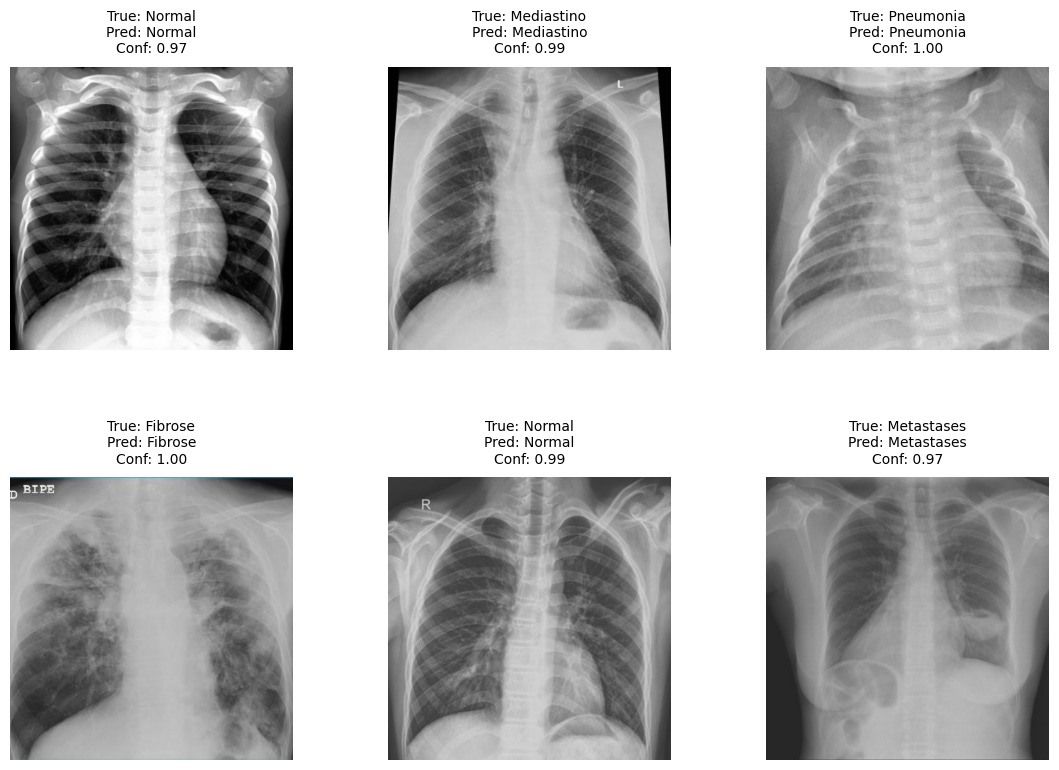

In [26]:
sample_rows = test_df.sample(6, random_state=SEED).reset_index(drop=True)

plt.figure(figsize=(14, 9))

for i, row in sample_rows.iterrows():
    img_path = row["filepath"]
    true_label = clean_label(row["label"])

    img, pred_label, confidence = predict_image_vgg_svm(img_path)

    if img is None:
        continue

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(
        f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}",
        fontsize=10,
        pad=10
    )
    plt.axis("off")

plt.subplots_adjust(hspace=0.45, wspace=0.15)
plt.show()

## 17. LIME

In [27]:
def load_rgb_image(img_path, size=IMG_SIZE):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    return img.astype(np.uint8)


def predict_for_lime(images):
    images = np.array(images).astype(np.float32)
    images = preprocess_input(images.copy())
    features = feature_extractor.predict(images, verbose=0)
    return svm_model.predict_proba(features)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

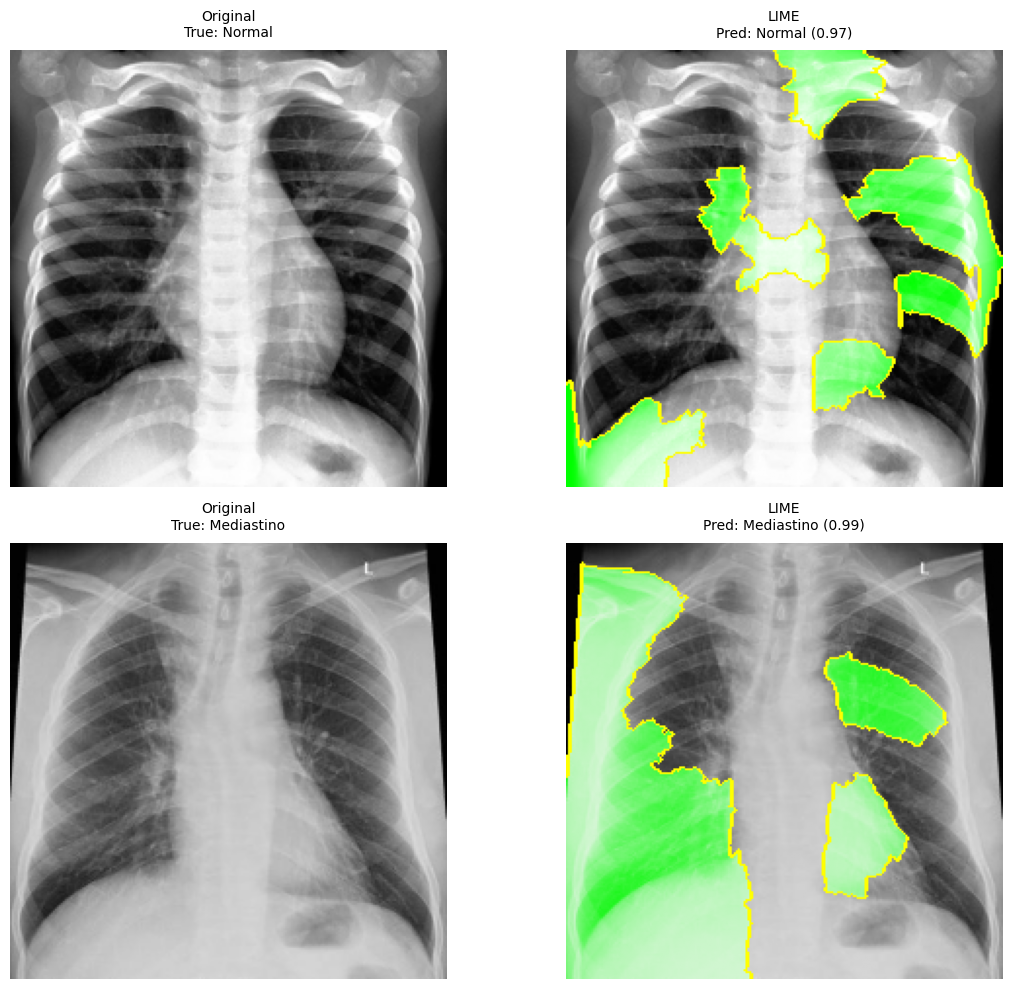

In [29]:
lime_explainer = lime_image.LimeImageExplainer()

lime_rows = test_df.sample(2, random_state=SEED).reset_index(drop=True)

plt.figure(figsize=(12, 10))

for i, row in lime_rows.iterrows():
    img_path = row["filepath"]
    true_label = clean_label(row["label"])

    img = load_rgb_image(img_path)

    preds = predict_for_lime(np.expand_dims(img, axis=0))
    pred_idx = int(np.argmax(preds[0]))
    pred_label = clean_label(class_names[pred_idx])
    confidence = float(preds[0][pred_idx])

    explanation = lime_explainer.explain_instance(
        image=img,
        classifier_fn=predict_for_lime,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )

    lime_img, lime_mask = explanation.get_image_and_mask(
        label=pred_idx,
        positive_only=False,
        num_features=8,
        hide_rest=False
    )

    plt.subplot(2, 2, 2 * i + 1)
    plt.imshow(img)
    plt.title(
        f"Original\nTrue: {true_label}",
        fontsize=10,
        pad=10
    )
    plt.axis("off")

    plt.subplot(2, 2, 2 * i + 2)
    plt.imshow(mark_boundaries(lime_img / 255.0, lime_mask))
    plt.title(
        f"LIME\nPred: {pred_label} ({confidence:.2f})",
        fontsize=10,
        pad=10
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## 18. SHAP on Extracted Features

In [32]:
!pip install shap -q

import shap
import numpy as np
import matplotlib.pyplot as plt

X_background = X_train[:50]
X_sample = X_test[:3]
y_sample = y_test[:3]

print("Background:", X_background.shape)
print("Samples to explain:", X_sample.shape)

Background: (50, 512)
Samples to explain: (3, 512)


In [33]:
explainer = shap.KernelExplainer(
    svm_model.predict_proba,
    X_background
)

shap_values = explainer.shap_values(
    X_sample,
    nsamples=100
)

pred_probs = svm_model.predict_proba(X_sample)
pred_classes = np.argmax(pred_probs, axis=1)

  0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/shap/explainers/_kernel.py:765: UserWarning: Linear regression equation is singular, a least squares solutions is used instead.
To avoid this situation and get a regular matrix do one of the following:
1) turn up the number of samples,
2) turn up the L1 regularization with num_features(N) where N is less than the number of samples,
3) group features together to reduce the number of inputs that need to be explained.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 2 iterations, i.e. alpha=1.581e-02, with an active set of 2 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/shap/explainers/_kernel.py:765: UserWarning: Linear regression equation is singular, a least squares solutions is used instead.

Sample: 1
True: Mediastino
Pred: Mediastino
Confidence: 0.99


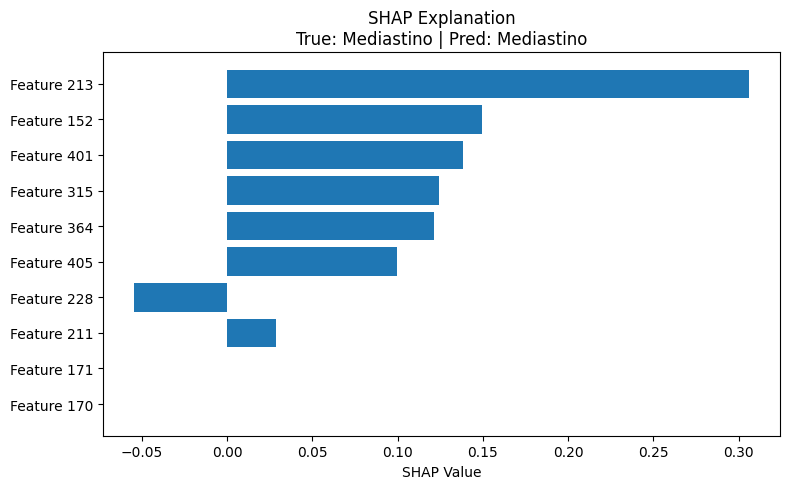

Sample: 2
True: Doenças Pulmonares O
Pred: Doenças Pulmonares O
Confidence: 0.99


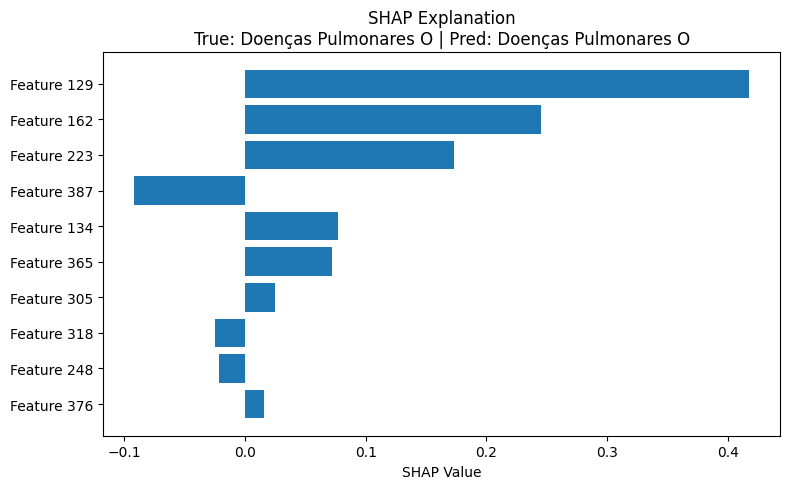

Sample: 3
True: Maior Densidade (Der
Pred: Maior Densidade (Der
Confidence: 1.0


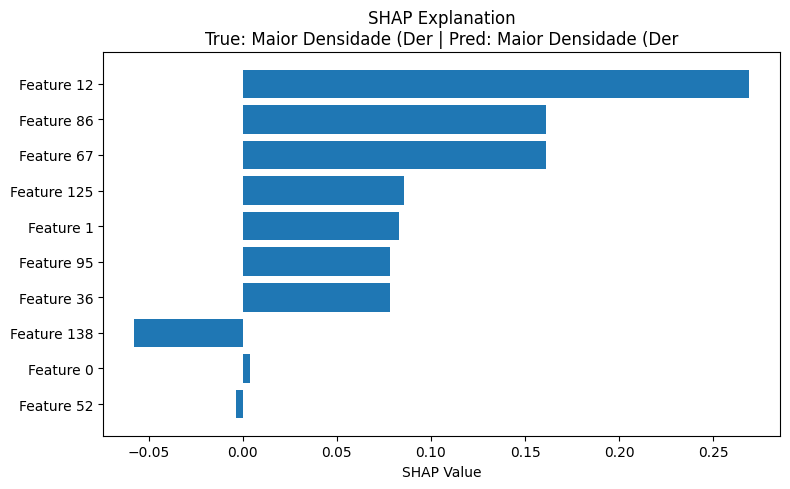

In [34]:
for sample_id in range(len(X_sample)):
    pred_class = pred_classes[sample_id]
    confidence = pred_probs[sample_id][pred_class]

    if isinstance(shap_values, list):
        sample_shap = shap_values[pred_class][sample_id]
    else:
        sample_shap = shap_values[sample_id, :, pred_class]

    top_features = np.argsort(np.abs(sample_shap))[-10:]

    print("=" * 50)
    print("Sample:", sample_id + 1)
    print("True:", clean_label(class_names[y_sample[sample_id]]))
    print("Pred:", clean_label(class_names[pred_class]))
    print("Confidence:", round(confidence, 2))

    plt.figure(figsize=(8, 5))
    plt.barh(
        [f"Feature {i}" for i in top_features],
        sample_shap[top_features]
    )
    plt.xlabel("SHAP Value")
    plt.title(
        f"SHAP Explanation\n"
        f"True: {clean_label(class_names[y_sample[sample_id]])} | "
        f"Pred: {clean_label(class_names[pred_class])}"
    )
    plt.tight_layout()
    plt.show()